# Module 5 — Pipeline Multimodal

Ce module couvre :
1. Chargement et préparation des features numériques + textuelles
2. Fusion par `hstack` sparse et `ColumnTransformer`
3. Pondération relative NLP / numérique
4. Classificateurs sur features fusionnées
5. Stacking de modèles (StackingClassifier)
6. Comparaison finale et sauvegarde


## ⚙️ 0. Imports


In [2]:
import os, re, warnings, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

from scipy.sparse import hstack, csr_matrix

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import ComplementNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

warnings.filterwarnings('ignore')
os.makedirs('outputs', exist_ok=True)
SEED = 42

for r in ['punkt', 'stopwords', 'punkt_tab']:
    nltk.download(r, quiet=True)

print('✅ Imports OK')

✅ Imports OK


## 📂 1. Chargement du Dataset


In [5]:
# ─────────────────────────────────────────────────────────────────
# Adapter ces variables selon votre dataset
DATA_PATH    = 'outputs/full_cleaned.csv'
TEXT_COL     = 'Rapport_Collecte'                          # colonne texte
NUM_FEATURES = ['Poids','Volume','Conductivite','Opacite','Rigidite']
LABEL_COL    = 'Categorie'
# ─────────────────────────────────────────────────────────────────

if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
    # Vérifier que les colonnes existent
    missing = [c for c in [TEXT_COL, LABEL_COL] + NUM_FEATURES if c not in df.columns]
    if missing:
        print(f'⚠️  Colonnes manquantes : {missing}')
        print(f'   Colonnes disponibles : {list(df.columns)}')
else:
    # ── Dataset de démonstration ──────────────────────────────
    print('⚠️  Fichier non trouvé — génération d\'un dataset de démonstration.')
    np.random.seed(SEED)
    n = 500
    categories = ['Metal', 'Bois', 'Plastique', 'Composite', 'Ceramique']
    cat_params = {
        'Metal':     dict(poids=(7,2),   vol=(100,30), cond=(50,10), opac=(0.9,0.05), rig=(200,40),
                          desc='acier aluminium métal conducteur rigide résistant alliage ferreux'),
        'Bois':      dict(poids=(0.6,0.2),vol=(800,200),cond=(0.1,0.05),opac=(0.8,0.1),rig=(10,3),
                          desc='bois chêne hêtre pin forêt fibre cellulose naturel organique'),
        'Plastique': dict(poids=(1.2,0.3),vol=(500,150),cond=(0.2,0.05),opac=(0.4,0.2),rig=(30,10),
                          desc='plastique polymère PVC ABS résine injection moulage flexible'),
        'Composite': dict(poids=(2,0.5), vol=(300,80), cond=(5,2),    opac=(0.7,0.1), rig=(150,30),
                          desc='composite carbone fibre époxy sandwich hybride renfort matrice'),
        'Ceramique': dict(poids=(3,0.8), vol=(200,60), cond=(1,0.3),  opac=(0.95,0.03),rig=(300,50),
                          desc='céramique verre porcelaine frittage zircone réfractaire cuisson'),
    }
    rows = []
    for cat, p in cat_params.items():
        for _ in range(n // len(categories)):
            words = p['desc'].split()
            desc  = ' '.join(np.random.choice(words, size=8, replace=True)) + \
                    f' qualité {np.random.randint(1,5)} épaisseur {np.random.randint(1,50)}mm'
            rows.append({
                TEXT_COL:       desc,
                'Poids':        max(0.1, np.random.normal(*p['poids'])),
                'Volume':       max(1,   np.random.normal(*p['vol'])),
                'Conductivite': max(0,   np.random.normal(*p['cond'])),
                'Opacite':      np.clip(np.random.normal(*p['opac']), 0, 1),
                'Rigidite':     max(0,   np.random.normal(*p['rig'])),
                LABEL_COL:      cat,
            })
    df = pd.DataFrame(rows)

NUM_FEATURES = [c for c in NUM_FEATURES if c in df.columns]
df = df.dropna(subset=[TEXT_COL, LABEL_COL] + NUM_FEATURES).reset_index(drop=True)

print(f'Shape      : {df.shape}')
print(f'Features   : {NUM_FEATURES}')
print(f'Classes    : {df[LABEL_COL].value_counts().to_dict()}')
df.head(3)

Shape      : (9986, 8)
Features   : ['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite']
Classes    : {'Plastique': 2795, 'Verre': 2586, 'Papier': 2318, 'Métal': 2287}


,Poids,Volume,Conductivite,Opacite,Rigidite,Prix_Revente,Categorie,Rapport_Collecte
0,16.708780,70.940977,0.0,1.000000,1.0,0.835439,Papier,Lot de papier récupéré dans un site non rensei...
1,47.277476,64.702925,0.0,2.204796,3.0,4.727748,Plastique,"Lot plastique à l'Usine A. Volume 64.7 L, poid..."
2,140.393004,317.415183,0.0,0.026234,9.0,4.211790,Verre,Bris de verre ou contenants en provenance de l...


## 🔤 2. Prétraitement Textuel


In [6]:
STOP_FR = set(stopwords.words('french'))
STOP_DOMAIN = {'utilisation','usage','haute','haut','bon','bonne','grand',
               'grande','type','produit','matériau','excellent','application'}
ALL_STOPS = STOP_FR | STOP_DOMAIN
stemmer   = SnowballStemmer('french')

def preprocess(text):
    text   = str(text).lower()
    text   = re.sub(r'[^a-zàâäéèêëîïôùûüÿç\s]', ' ', text)
    tokens = word_tokenize(text, language='french')
    tokens = [stemmer.stem(t) for t in tokens
              if t not in ALL_STOPS and len(t) > 2]
    return ' '.join(tokens)

df['text_processed'] = df[TEXT_COL].apply(preprocess)

print('Exemple :')
print(f'  Original  : {df[TEXT_COL].iloc[0]}')
print(f'  Traité    : {df["text_processed"].iloc[0]}')

Exemple :
  Original  : Lot de papier récupéré dans un site non renseigné. Poids léger de 16.7 kg, volume moyen. Matériau souple, non conducteur, aspect très opaque. Bon état général.
  Traité    : lot papi récuper sit non renseign poid leg volum moyen soupl non conducteur aspect tres opaqu état général


## ✂️ 3. Split Train / Test


In [8]:
le = LabelEncoder()
y  = le.fit_transform(df[LABEL_COL])
CLASSES = list(le.classes_)

idx_train, idx_test = train_test_split(
    np.arange(len(df)), test_size=0.2, stratify=y, random_state=SEED
)

y_train = y[idx_train]
y_test  = y[idx_test]

# Texte
text_train = df['text_processed'].iloc[idx_train].values
text_test  = df['text_processed'].iloc[idx_test].values

# Numérique
X_num_train = df[NUM_FEATURES].iloc[idx_train].values.astype(float)
X_num_test  = df[NUM_FEATURES].iloc[idx_test].values.astype(float)

print(f'Train : {len(idx_train)}  |  Test : {len(idx_test)}')

Train : 7988  |  Test : 1998


## 🔗 4. Fusion des Features

### 4.1 TF-IDF seul (baseline NLP)


In [9]:
tfidf = TfidfVectorizer(max_features=6000, ngram_range=(1,2),
                         sublinear_tf=True, min_df=2)
X_nlp_train = tfidf.fit_transform(text_train)
X_nlp_test  = tfidf.transform(text_test)

print(f'TF-IDF seul  → {X_nlp_train.shape}')

TF-IDF seul  → (7988, 597)


### 4.2 Numérique seul (baseline numérique)


In [10]:
scaler = StandardScaler()
X_num_sc_train = scaler.fit_transform(X_num_train)
X_num_sc_test  = scaler.transform(X_num_test)

print(f'Numérique    → {X_num_sc_train.shape}')

Numérique    → (7988, 5)


### 4.3 Fusion hstack (concaténation sparse)


In [11]:
# Convertir le numérique scalé en sparse puis concaténer
X_fused_train = hstack([X_nlp_train, csr_matrix(X_num_sc_train)])
X_fused_test  = hstack([X_nlp_test,  csr_matrix(X_num_sc_test)])

print(f'Fusion hstack → {X_fused_train.shape}')
print(f'  dont TF-IDF : {X_nlp_train.shape[1]} features')
print(f'  dont num    : {X_num_sc_train.shape[1]} features')

Fusion hstack → (7988, 602)
  dont TF-IDF : 597 features
  dont num    : 5 features


### 4.4 ColumnTransformer (pipeline reproductible)


In [12]:
# Reconstruire un DataFrame pour ColumnTransformer
df_train_ct = df.iloc[idx_train].reset_index(drop=True)
df_test_ct  = df.iloc[idx_test].reset_index(drop=True)

col_transformer = ColumnTransformer(
    transformers=[
        ('nlp', TfidfVectorizer(max_features=6000, ngram_range=(1,2),
                                sublinear_tf=True, min_df=2), 'text_processed'),
        ('num', StandardScaler(), NUM_FEATURES),
    ],
    remainder='drop'
)

X_ct_train = col_transformer.fit_transform(df_train_ct)
X_ct_test  = col_transformer.transform(df_test_ct)

print(f'ColumnTransformer → {X_ct_train.shape}')
print('Pipeline reproductible ✅')

ColumnTransformer → (7988, 602)
Pipeline reproductible ✅


## ⚖️ 5. Pondération Relative NLP / Numérique


  alpha=0.00  (NLP=0% / Num=100%)  Acc=0.9920  F1=0.9920
  alpha=0.25  (NLP=25% / Num=75%)  Acc=0.9930  F1=0.9930
  alpha=0.50  (NLP=50% / Num=50%)  Acc=0.9930  F1=0.9930
  alpha=0.75  (NLP=75% / Num=25%)  Acc=0.9980  F1=0.9980
  alpha=1.00  (NLP=100% / Num=0%)  Acc=1.0000  F1=1.0000


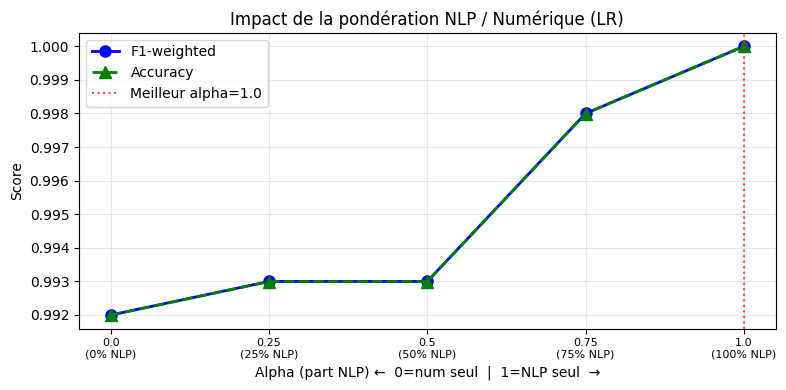


Meilleur alpha : 1.0  (NLP=100% / Num=0%)


In [13]:
def build_weighted(X_nlp, X_num, alpha):
    """
    Fusion pondérée : alpha * NLP + (1-alpha) * Numérique.
    alpha=1.0 → NLP seul | alpha=0.0 → numérique seul
    """
    return hstack([
        X_nlp  * alpha,
        csr_matrix(X_num) * (1.0 - alpha)
    ])

alphas   = [0.0, 0.25, 0.5, 0.75, 1.0]
alpha_results = []

clf_alpha = LogisticRegression(max_iter=1000, C=1.0, random_state=SEED)

for a in alphas:
    Xtr = build_weighted(X_nlp_train, X_num_sc_train, a)
    Xte = build_weighted(X_nlp_test,  X_num_sc_test,  a)
    clf_alpha.fit(Xtr, y_train)
    pred = clf_alpha.predict(Xte)
    acc  = accuracy_score(y_test, pred)
    f1   = f1_score(y_test, pred, average='weighted')
    alpha_results.append({'alpha (NLP)': a, 'Accuracy': acc, 'F1-weighted': f1})
    print(f'  alpha={a:.2f}  (NLP={a*100:.0f}% / Num={(1-a)*100:.0f}%)'
          f'  Acc={acc:.4f}  F1={f1:.4f}')

df_alpha = pd.DataFrame(alpha_results)

# Visualisation
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df_alpha['alpha (NLP)'], df_alpha['F1-weighted'],
        'bo-', linewidth=2, markersize=8, label='F1-weighted')
ax.plot(df_alpha['alpha (NLP)'], df_alpha['Accuracy'],
        'g^--', linewidth=2, markersize=8, label='Accuracy')
best_a = df_alpha.loc[df_alpha['F1-weighted'].idxmax(), 'alpha (NLP)']
ax.axvline(x=best_a, color='red', linestyle=':', alpha=0.7,
           label=f'Meilleur alpha={best_a}')
ax.set_xlabel('Alpha (part NLP) ←  0=num seul  |  1=NLP seul  →')
ax.set_ylabel('Score')
ax.set_title('Impact de la pondération NLP / Numérique (LR)')
ax.set_xticks(alphas)
ax.set_xticklabels([f'{a}\n({int(a*100)}% NLP)' for a in alphas], fontsize=8)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/weighting_alpha.png', dpi=120)
plt.show()

print(f'\nMeilleur alpha : {best_a}  (NLP={int(best_a*100)}% / Num={int((1-best_a)*100)}%)')

## 🤖 6. Classificateurs sur Features Fusionnées


In [14]:
all_results = []

def evaluate(name, clf, X_tr, X_te, y_tr, y_te):
    clf.fit(X_tr, y_tr)
    pred = clf.predict(X_te)
    acc  = accuracy_score(y_te, pred)
    f1   = f1_score(y_te, pred, average='weighted')
    all_results.append({'Modèle': name, 'Accuracy': round(acc,4),
                        'F1-weighted': round(f1,4)})
    print(f'{name:45s}  Acc={acc:.4f}  F1={f1:.4f}')
    return clf, pred

# ── Baselines ────────────────────────────────────────────────
print('=== BASELINES ===')
evaluate('TF-IDF seul + LinearSVC',
         LinearSVC(C=1.0, max_iter=2000, random_state=SEED),
         X_nlp_train, X_nlp_test, y_train, y_test)

evaluate('Numérique seul + LR',
         LogisticRegression(max_iter=1000, C=1.0, random_state=SEED),
         X_num_sc_train, X_num_sc_test, y_train, y_test)

# ── Fusion hstack ─────────────────────────────────────────────
print('\n=== FUSION hstack ===')
evaluate('Fusion (hstack) + LinearSVC',
         LinearSVC(C=1.0, max_iter=2000, random_state=SEED),
         X_fused_train, X_fused_test, y_train, y_test)

evaluate('Fusion (hstack) + Logistic Regression',
         LogisticRegression(max_iter=1000, C=1.0, random_state=SEED),
         X_fused_train, X_fused_test, y_train, y_test)

evaluate('Fusion (hstack) + Random Forest',
         RandomForestClassifier(n_estimators=200, random_state=SEED),
         X_fused_train, X_fused_test, y_train, y_test)

# ── ColumnTransformer ─────────────────────────────────────────
print('\n=== COLUMN TRANSFORMER ===')
evaluate('ColumnTransformer + LinearSVC',
         LinearSVC(C=1.0, max_iter=2000, random_state=SEED),
         X_ct_train, X_ct_test, y_train, y_test)

evaluate('ColumnTransformer + LR',
         LogisticRegression(max_iter=1000, C=1.0, random_state=SEED),
         X_ct_train, X_ct_test, y_train, y_test)

# ── Pondération optimale ──────────────────────────────────────
print('\n=== PONDÉRATION OPTIMALE ===')
X_opt_tr = build_weighted(X_nlp_train, X_num_sc_train, best_a)
X_opt_te = build_weighted(X_nlp_test,  X_num_sc_test,  best_a)
evaluate(f'Pondéré alpha={best_a} + LinearSVC',
         LinearSVC(C=1.0, max_iter=2000, random_state=SEED),
         X_opt_tr, X_opt_te, y_train, y_test)
evaluate(f'Pondéré alpha={best_a} + LR',
         LogisticRegression(max_iter=1000, C=1.0, random_state=SEED),
         X_opt_tr, X_opt_te, y_train, y_test)

=== BASELINES ===
TF-IDF seul + LinearSVC                        Acc=1.0000  F1=1.0000
Numérique seul + LR                            Acc=0.9920  F1=0.9920

=== FUSION hstack ===
Fusion (hstack) + LinearSVC                    Acc=1.0000  F1=1.0000
Fusion (hstack) + Logistic Regression          Acc=0.9975  F1=0.9975
Fusion (hstack) + Random Forest                Acc=1.0000  F1=1.0000

=== COLUMN TRANSFORMER ===
ColumnTransformer + LinearSVC                  Acc=1.0000  F1=1.0000
ColumnTransformer + LR                         Acc=0.9975  F1=0.9975

=== PONDÉRATION OPTIMALE ===
Pondéré alpha=1.0 + LinearSVC                  Acc=1.0000  F1=1.0000
Pondéré alpha=1.0 + LR                         Acc=1.0000  F1=1.0000


(LogisticRegression(max_iter=1000, random_state=42),
 array([0, 1, 2, ..., 0, 1, 3]))

## 🏗️ 7. Stacking de Modèles


In [15]:
print('=== STACKING ===')

# ── Niveau 0 : estimateurs de base ───────────────────────────
base_estimators = [
    ('svc',  LinearSVC(C=1.0, max_iter=2000, random_state=SEED)),
    ('lr',   LogisticRegression(max_iter=1000, C=1.0, random_state=SEED)),
    ('rf',   RandomForestClassifier(n_estimators=100, random_state=SEED)),
]

# ── Niveau 1 : méta-classifieur ───────────────────────────────
meta_clf = LogisticRegression(max_iter=1000, C=1.0, random_state=SEED)

stacker = StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta_clf,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    passthrough=False,          # ne passer que les proba/décisions
    n_jobs=-1
)

print('Entraînement du Stacker (CV 5-fold)...')
stacker.fit(X_fused_train, y_train)
stacker_pred = stacker.predict(X_fused_test)
stk_acc = accuracy_score(y_test, stacker_pred)
stk_f1  = f1_score(y_test, stacker_pred, average='weighted')
all_results.append({'Modèle': 'Stacking (SVC+LR+RF) → LR',
                    'Accuracy': round(stk_acc,4), 'F1-weighted': round(stk_f1,4)})

print(f'Stacking (SVC+LR+RF) → LR    Acc={stk_acc:.4f}  F1={stk_f1:.4f}')

# ── Variante : Stacking sur ColumnTransformer ─────────────────
stacker2 = StackingClassifier(
    estimators=[
        ('svc', LinearSVC(C=1.0, max_iter=2000, random_state=SEED)),
        ('lr',  LogisticRegression(max_iter=1000, C=1.0, random_state=SEED)),
    ],
    final_estimator=LogisticRegression(max_iter=500, random_state=SEED),
    cv=5, n_jobs=-1
)
stacker2.fit(X_ct_train, y_train)
st2_pred = stacker2.predict(X_ct_test)
st2_acc  = accuracy_score(y_test, st2_pred)
st2_f1   = f1_score(y_test, st2_pred, average='weighted')
all_results.append({'Modèle': 'Stacking (SVC+LR) → LR [ColTransformer]',
                    'Accuracy': round(st2_acc,4), 'F1-weighted': round(st2_f1,4)})

print(f'Stacking (SVC+LR) ColumnTransformer    Acc={st2_acc:.4f}  F1={st2_f1:.4f}')

=== STACKING ===
Entraînement du Stacker (CV 5-fold)...
Stacking (SVC+LR+RF) → LR    Acc=1.0000  F1=1.0000
Stacking (SVC+LR) ColumnTransformer    Acc=1.0000  F1=1.0000


## 📊 8. Comparaison Finale


=== RÉSUMÉ COMPARATIF ===


,Modèle,Accuracy,F1-weighted
0,TF-IDF seul + LinearSVC,1.0000,1.0000
1,Fusion (hstack) + LinearSVC,1.0000,1.0000
2,Fusion (hstack) + Random Forest,1.0000,1.0000
3,ColumnTransformer + LinearSVC,1.0000,1.0000
4,Pondéré alpha=1.0 + LinearSVC,1.0000,1.0000
5,Pondéré alpha=1.0 + LR,1.0000,1.0000
6,Stacking (SVC+LR+RF) → LR,1.0000,1.0000
7,Stacking (SVC+LR) → LR [ColTransformer],1.0000,1.0000
8,Fusion (hstack) + Logistic Regression,0.9975,0.9975
9,ColumnTransformer + LR,0.9975,0.9975


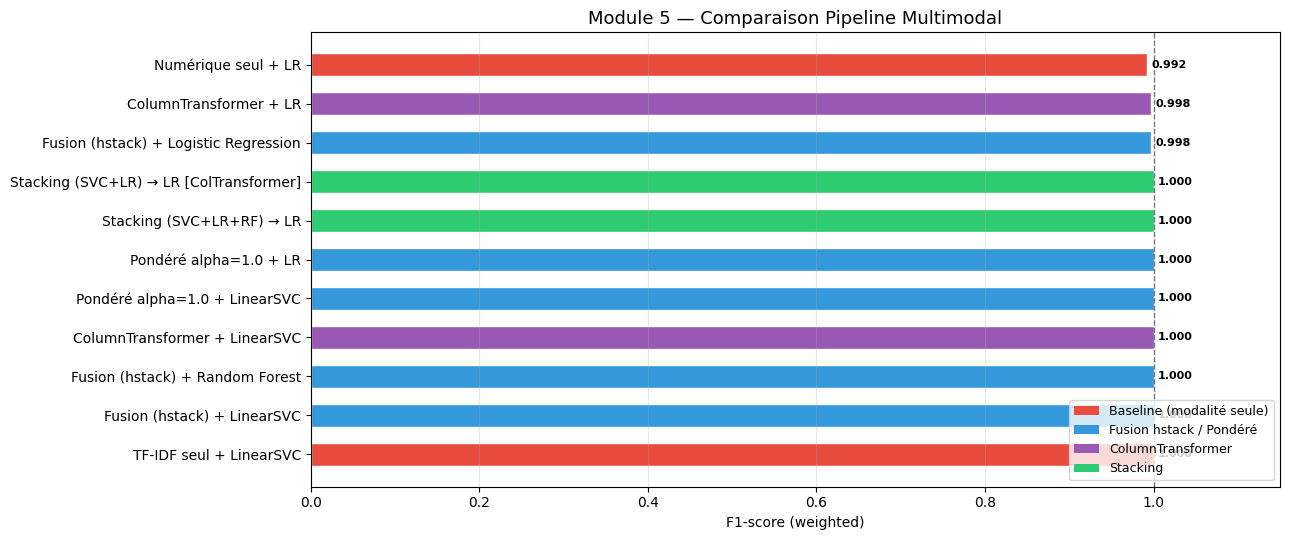


🏆 Meilleur modèle : TF-IDF seul + LinearSVC
   Accuracy    : 1.0000
   F1-weighted : 1.0000


In [16]:
df_final = pd.DataFrame(all_results).sort_values('F1-weighted', ascending=False).reset_index(drop=True)
print('=== RÉSUMÉ COMPARATIF ===')
display(df_final)

# ── Graphique comparatif ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, max(5, len(df_final)*0.5)))

colors = ['#2ecc71' if 'Stacking' in r else
          '#3498db' if 'Pondéré' in r or 'hstack' in r.lower() else
          '#e74c3c' if 'seul' in r else
          '#9b59b6'
          for r in df_final['Modèle']]

bars = ax.barh(df_final['Modèle'], df_final['F1-weighted'],
               color=colors, edgecolor='white', height=0.6)

for bar, acc in zip(bars, df_final['Accuracy']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.3f}', va='center', fontsize=8, fontweight='bold')

ax.set_xlabel('F1-score (weighted)')
ax.set_title('Module 5 — Comparaison Pipeline Multimodal', fontsize=13)
ax.set_xlim(0, 1.15)
ax.axvline(x=df_final['F1-weighted'].max(), color='black',
           linestyle='--', alpha=0.5, linewidth=1)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='Baseline (modalité seule)'),
    Patch(facecolor='#3498db', label='Fusion hstack / Pondéré'),
    Patch(facecolor='#9b59b6', label='ColumnTransformer'),
    Patch(facecolor='#2ecc71', label='Stacking'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/multimodal_comparison.png', dpi=120)
plt.show()

best = df_final.iloc[0]
print(f'\n🏆 Meilleur modèle : {best["Modèle"]}')
print(f'   Accuracy    : {best["Accuracy"]:.4f}')
print(f'   F1-weighted : {best["F1-weighted"]:.4f}')

## 🗂️ 9. Matrice de Confusion — Meilleur Modèle


Rapport de classification — Fusion hstack + LinearSVC :
              precision    recall  f1-score   support

       Métal       1.00      1.00      1.00       458
      Papier       1.00      1.00      1.00       464
   Plastique       1.00      1.00      1.00       559
       Verre       1.00      1.00      1.00       517

    accuracy                           1.00      1998
   macro avg       1.00      1.00      1.00      1998
weighted avg       1.00      1.00      1.00      1998



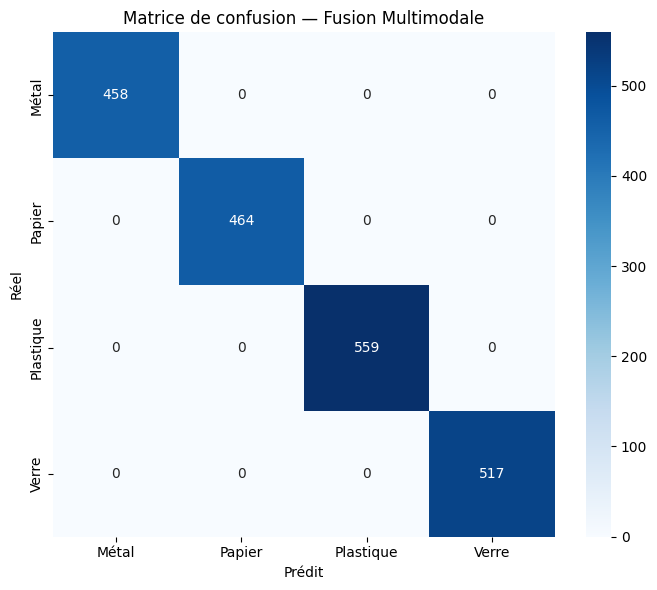

In [17]:
# Ré-entraîner le meilleur modèle (stacker ou ColumnTransformer+LinearSVC)
final_clf = LinearSVC(C=1.0, max_iter=2000, random_state=SEED)
final_clf.fit(X_fused_train, y_train)
y_final = final_clf.predict(X_fused_test)

print('Rapport de classification — Fusion hstack + LinearSVC :')
print(classification_report(y_test, y_final, target_names=CLASSES))

cm = confusion_matrix(y_test, y_final)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Matrice de confusion — Fusion Multimodale')
plt.ylabel('Réel')
plt.xlabel('Prédit')
plt.tight_layout()
plt.savefig('outputs/multimodal_confusion.png', dpi=120)
plt.show()

## 💾 10. Sauvegarde du Pipeline Final


In [18]:
# Pipeline sklearn complet et reproductible
full_pipeline = Pipeline([
    ('features', ColumnTransformer([
        ('nlp', TfidfVectorizer(max_features=6000, ngram_range=(1,2),
                                sublinear_tf=True, min_df=2), 'text_processed'),
        ('num', StandardScaler(), NUM_FEATURES),
    ])),
    ('clf', LinearSVC(C=1.0, max_iter=2000, random_state=SEED))
])

full_pipeline.fit(df.iloc[idx_train].reset_index(drop=True), y_train)

with open('outputs/multimodal_pipeline.pkl', 'wb') as f:
    pickle.dump({'pipeline': full_pipeline, 'label_encoder': le,
                 'num_features': NUM_FEATURES, 'text_col': 'text_processed'}, f)

df_final.to_csv('outputs/multimodal_results.csv', index=False)

print('✅ Sauvegardés :')
print('   outputs/multimodal_pipeline.pkl')
print('   outputs/multimodal_results.csv')
print('   outputs/multimodal_comparison.png')
print('   outputs/multimodal_confusion.png')
print('   outputs/weighting_alpha.png')

# ── Test rapide du pipeline sauvegardé ───────────────────────
test_row = df.iloc[idx_test[:3]].copy().reset_index(drop=True)
preds = le.inverse_transform(full_pipeline.predict(test_row))
reals = le.inverse_transform(y_test[:3])
print('\nTest pipeline :')
for i, (p, r) in enumerate(zip(preds, reals)):
    status = '✅' if p == r else '❌'
    print(f'  {status}  Prédit={p:12s}  Réel={r}')

✅ Sauvegardés :
   outputs/multimodal_pipeline.pkl
   outputs/multimodal_results.csv
   outputs/multimodal_comparison.png
   outputs/multimodal_confusion.png
   outputs/weighting_alpha.png

Test pipeline :
  ✅  Prédit=Métal         Réel=Métal
  ✅  Prédit=Papier        Réel=Papier
  ✅  Prédit=Plastique     Réel=Plastique
